# Customer Churn Analysis - Week 1 EDA
**Author**: Wayna Ali
**Date**: 04/01/2026
**Course**: Introduction to Applied AI
## Project Overview
This notebook performs exploratory data analysis on customer churn data to identify patterns and inform our predictive modeling approach.
## Table of Contents
1. Dataset Overview
2. Numerical Features Analysis
3. Categorical Features Analysis
4. Feature Correlations
5. Key Insights and Findings

In [2]:
# Data manipulation
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline
print('Libraries imported successfully!')

Libraries imported successfully!


In [4]:
import pandas as pd

# Load data (Kaggle path)
df = pd.read_csv("/kaggle/input/datasets/waynaali/churn-dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# First look
print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Streami

## 1. Dataset Overview

In [5]:
# 1.1 Column names and types
print('Column Information:')
df.info()

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043

In [6]:
# 1.2 Statistical summary
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
# 1.3 Check for missing values
print('Missing Values:')
missing = df.isnull().sum()
print(missing[missing > 0])
# Fix TotalCharges if needed
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

Missing Values:
Series([], dtype: int64)


In [8]:
# 1.4 Target variable distribution
print('Churn Distribution:')
print(df['Churn'].value_counts())
print('\nChurn Percentage:')
print(df['Churn'].value_counts(normalize=True) * 100)

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


### Key Findings:- Dataset has 7043 customers- Churn rate is 26.54%- 11 missing values in TotalCharges column- Features include demographic information (e.g., gender, partner, dependents), service usage details (e.g., internet service, streaming, security), and account-related attributes (e.g., contract type, payment method, monthly charges).

## 2. Numerical Features Analysis

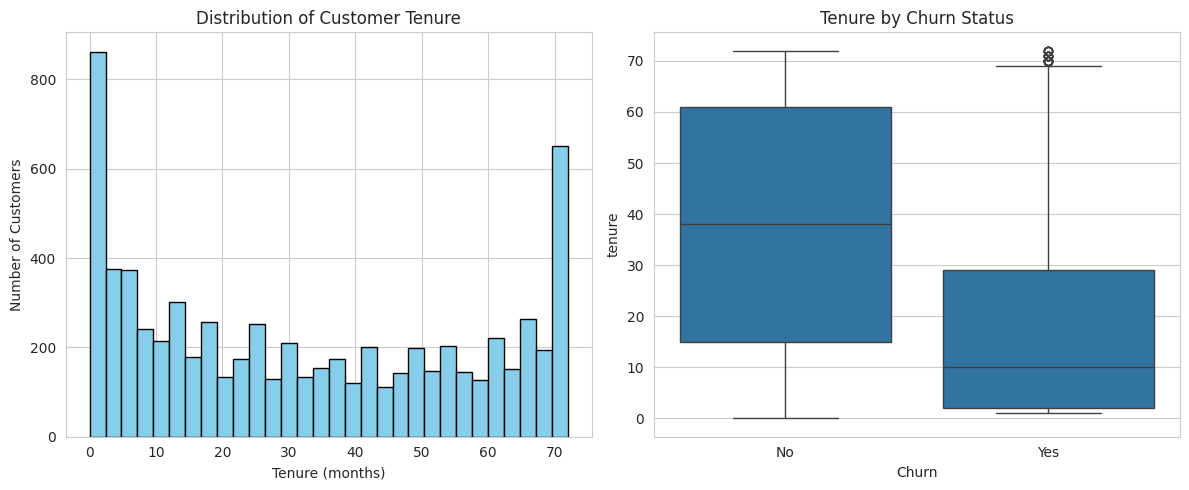

In [9]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['tenure'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Tenure')
plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure by Churn Status')
plt.tight_layout()
plt.show()

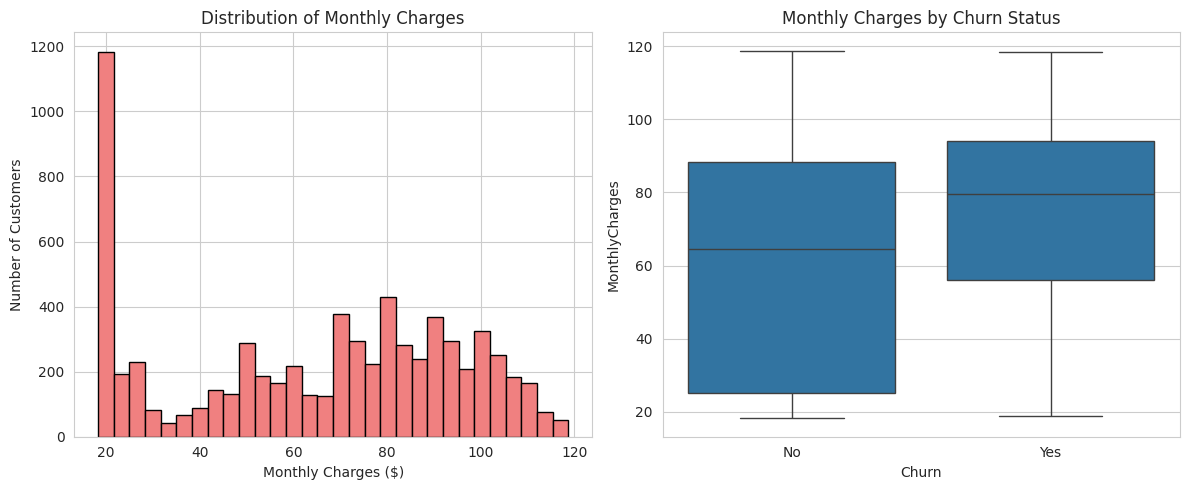

In [10]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['MonthlyCharges'], bins=30, color='lightcoral', edgecolor='black')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Monthly Charges')
plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Churn Status')
plt.tight_layout()
plt.show()

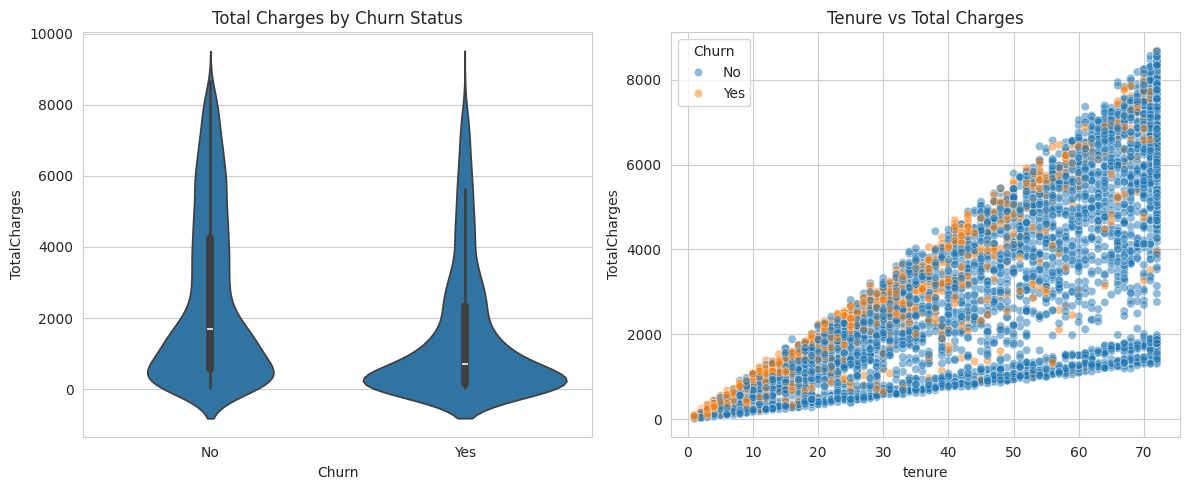

In [11]:
# Remove missing values for this plot
df_clean = df[df['TotalCharges'].notna()]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.violinplot(x='Churn', y='TotalCharges', data=df_clean)
plt.title('Total Charges by Churn Status')
plt.subplot(1, 2, 2)
sns.scatterplot(x='tenure', y='TotalCharges', hue='Churn', data=df_clean,
alpha=0.5)
plt.title('Tenure vs Total Charges')
plt.tight_layout()
plt.show()

### Numerical Features Insights:- 
Tenure: Customers with shorter tenure are more likely to churn.

Monthly Charges: Higher monthly charges are associated with a higher likelihood of churn.

Total Charges: Total charges are closely related to tenure; customers with longer tenure generally have higher total charges.


## 3. Categorical Features Analysis

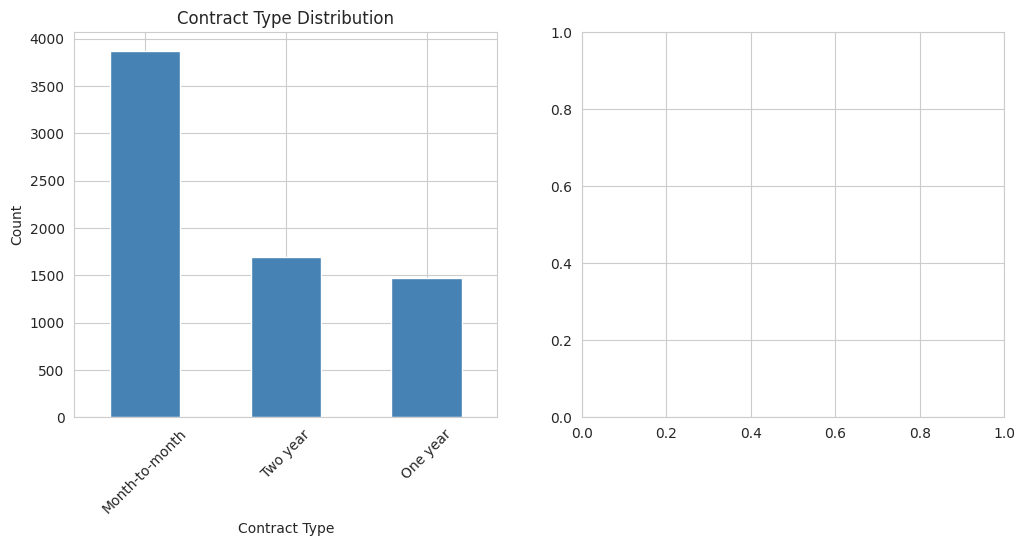

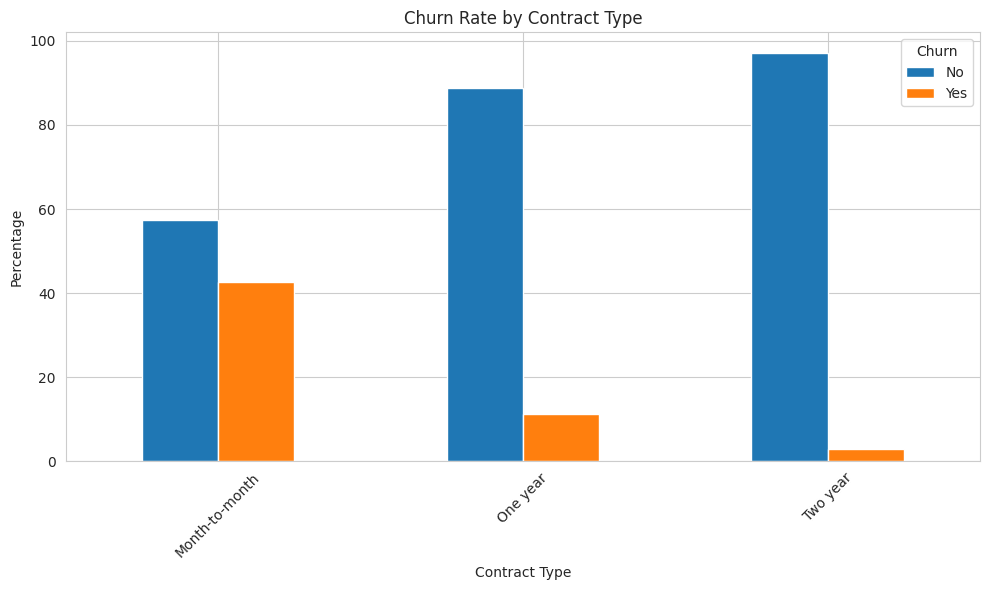

In [12]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df['Contract'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Contract Type Distribution')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', stacked=False)
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage')
plt.legend(title='Churn')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

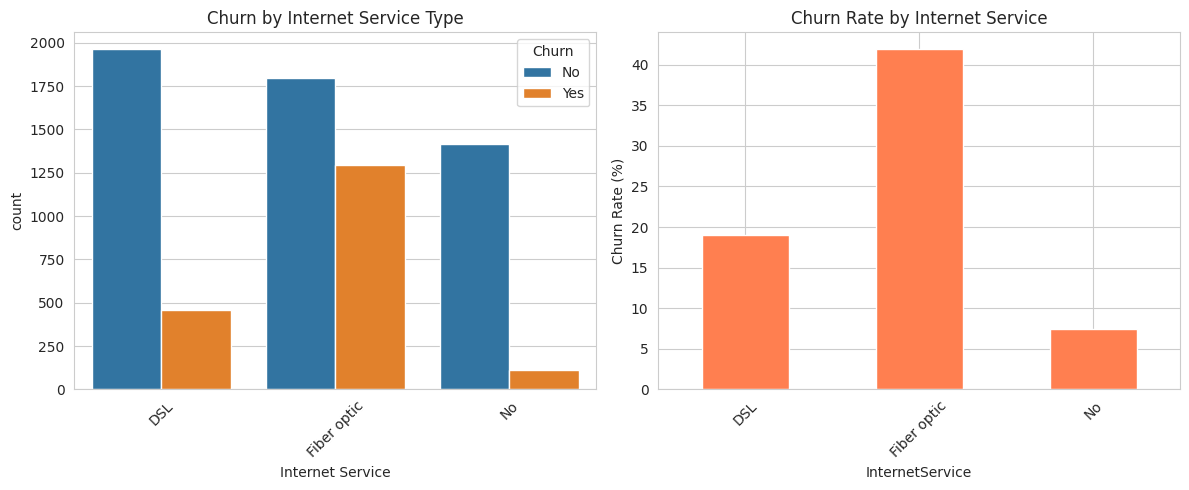

In [14]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index')* 100
internet_churn['Yes'].plot(kind='bar', color='coral')
plt.title('Churn Rate by Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

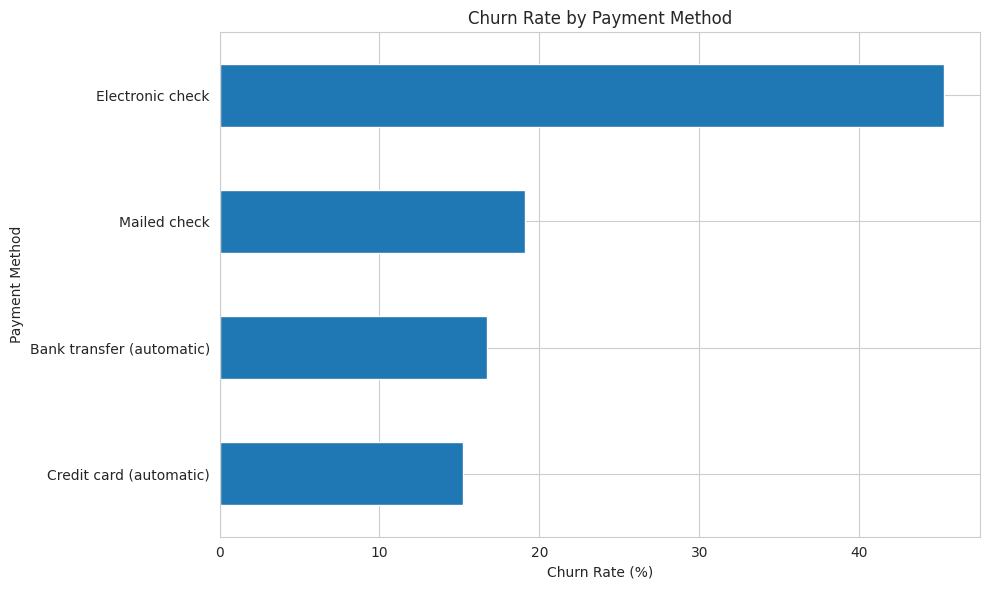

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

plt.figure(figsize=(10, 6))
payment_churn['Yes'].sort_values().plot(kind='barh')

plt.title('Churn Rate by Payment Method')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Payment Method')
plt.tight_layout()
plt.show()

## 4. Feature Correlations

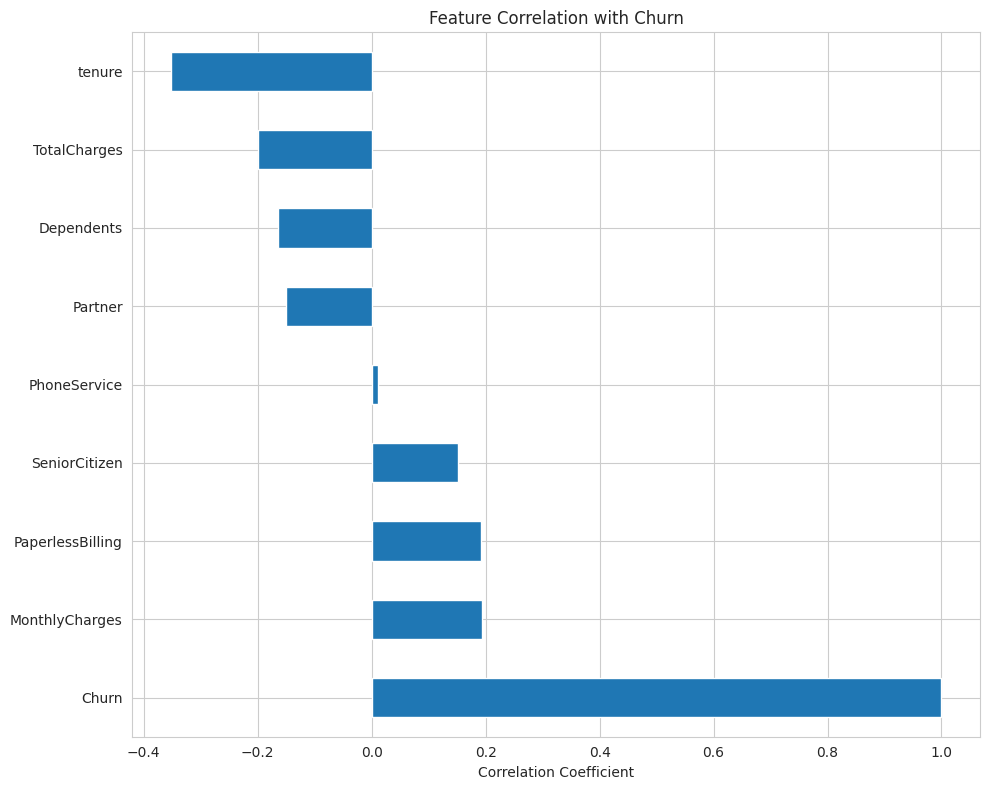

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Prepare numeric data
df_numeric = df.copy()

# Convert Yes/No to 1/0
binary_cols = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in binary_cols:
    if col in df_numeric.columns:
        df_numeric[col] = df_numeric[col].map({'Yes': 1, 'No': 0})

# Select only numeric columns
numeric_features = df_numeric.select_dtypes(include=[np.number])

# Correlation with Churn
plt.figure(figsize=(10, 8))

churn_corr = numeric_features.corr()['Churn'].sort_values(ascending=False)

churn_corr.plot(kind='barh')

plt.title('Feature Correlation with Churn')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

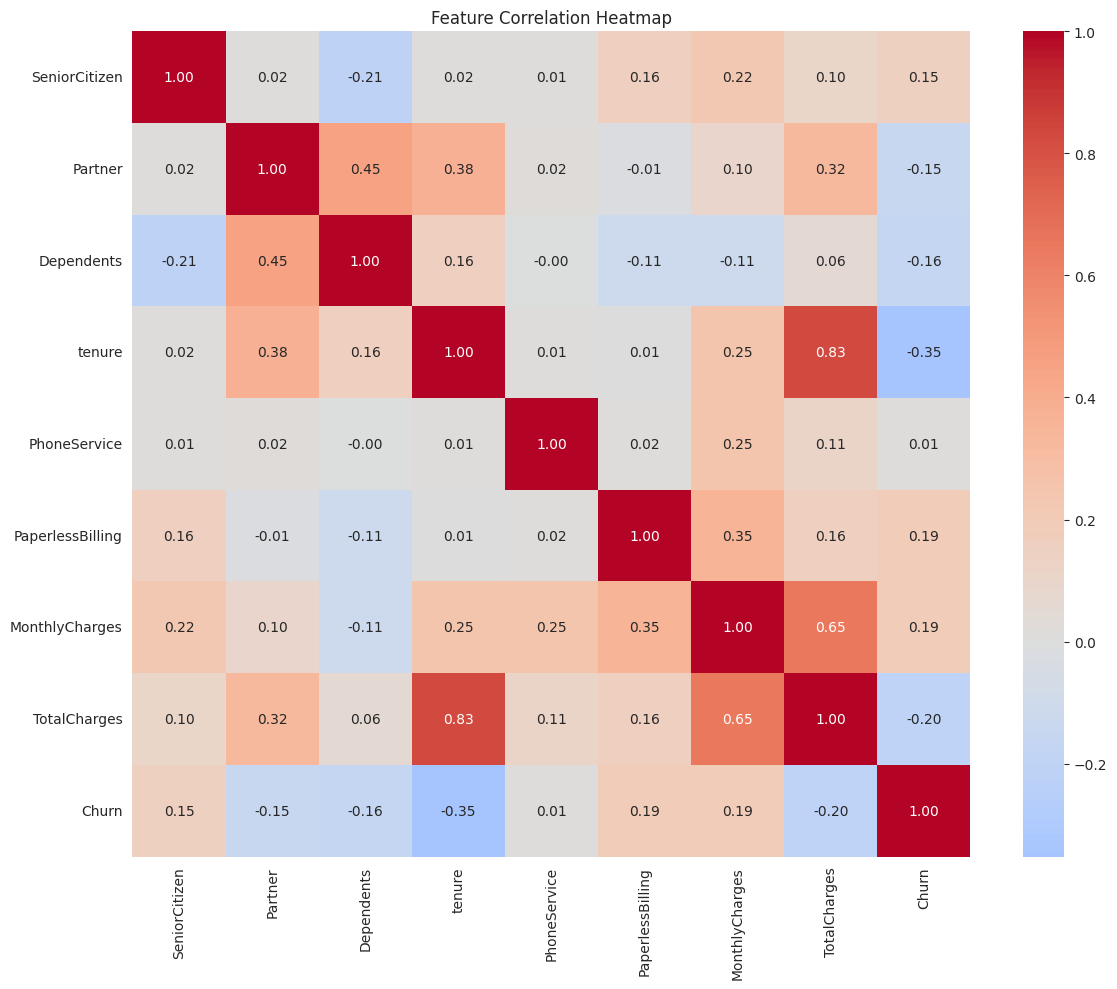

In [19]:
plt.figure(figsize=(12, 10))
correlation_matrix = numeric_features.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


## 5. Key Insights and Findings

### High-Risk Customer Characteristics

- **Contract Type:** Customers with month-to-month contracts have a higher churn rate (e.g., ~43%) compared to customers with one-year or two-year contracts (~11–15%).  
- **Tenure:** Customers with tenure less than 6 months are at higher risk of churning.  
- **Charges:** Customers with higher monthly charges tend to churn more frequently.  
- **Services:** Fiber optic internet users show a higher churn tendency compared to DSL or no internet.  
- **Payment Method:** Customers paying via electronic check have a higher likelihood of churn.

## 6. Personal Learning Summary

During this lab, I gained practical experience in **exploratory data analysis (EDA)** using **Python** and **Jupyter Notebook**. Key takeaways include:

### Data Loading and Inspection:
- Learned to load datasets with **Pandas (`read_csv`)** and explore basic information (**shape, head, info, describe**).  
- Checked for missing values and handled data type inconsistencies (e.g., converting **TotalCharges** to numeric).

### Numerical Data Analysis:
- Explored distributions of numerical features like **tenure, MonthlyCharges, and TotalCharges**.  
- Understood relationships between these features and churn using **histograms, boxplots, scatterplots, and violin plots**.  
- Observed that **short tenure** and **higher charges** correlate with **higher churn**.

### Categorical Data Analysis:
- Visualized categorical variables like **Contract, InternetService, and PaymentMethod** using **bar plots and countplots**.  
- Learned to compute churn rates per category using **crosstab** and normalized percentages.  
- Identified **high-risk groups**, e.g., **month-to-month contract holders** and **electronic check users**.

### Correlation Analysis:
- Converted binary features into numeric format to calculate correlations with **Churn**.  
- Created correlation **bar charts** and **heatmaps** to identify features strongly associated with churn.

### Visualization Skills:
- Practiced creating meaningful, clear, and well-labeled visualizations using **Matplotlib** and **Seaborn**.  
- Learned to combine multiple plots for comparative analysis and interpret insights visually.

### Documentation and GitHub Workflow:
- Organized notebooks with **markdown headers, insights, and commentary** for clarity.  
- Learned to create **.gitignore** and **README.md** files, push code to GitHub, and maintain version control.

**Overall**, this lab helped me build a strong foundation in **data exploration, pattern recognition, and documentation**. These skills will guide **feature engineering** and **model-building** in the next weeks of the Customer Churn Prediction project.